## Project Introduction


人口yes影响地区发展的重要因素。不同地区的人口年龄结构不仅yes本地区社会发展的一个体现，也yes其未来发展的基础。Analyze其了解有助于我们更好得理解社会的变化，Analyze社会发展有更正确的认识。  

本次从第7次人口普查数据的地区（省份）之间的人口年龄结构出发，分析人口年龄结构的差异及其影响因素。  

Conclusion：

- 第 7 次人口普查数据统计的2020年中国各地区（省份）的人口年龄结构，将人口分为14岁以下、15到59岁、60岁以上三个年龄段，based on年龄结构的相似度可以各个地区分为三组：  
	- 第 1 组：人口年龄结构特点yes**低高高**，大致yes 1:7:2。包括北京、天津、上海、浙江、东北三省和内蒙古。  
	- 第 2 组：人口年龄结构特点yes**高低高**，大致yes 2:6:2。包括以华北和华中为主的省份。  
	- 第 3 组：人口年龄结构特点特点yes**高高低**，大致yes 2:7:1。包括西藏、新疆、青海、广东、福建、海南等省份。  
- 地区间的人口年龄结构和地区经济发展水平相关性不高。  
- 14岁以下人口年龄比例差异主要受到城市化进程的影响。城市化水平越高，进度越早，则这部分人口年龄比例越容易较少。  
- 15-59岁之间人口年龄比例差异主要受到流动人口的影响。流动人口比例越大，则这部分人口年龄比例越容易更高。


涉及到的数据：

- 主数据，第七次全国人口普查数据  
	- 各地区人口年龄构成  
	- 各地区平均受教育年限  
	- 各地区人口  
- 额外数据  
	- 各地区2020年GDP，来自国家统计局-数据查询  
	- 各地区城市化数据，来自国家统计局-数据查询和统计年鉴  
	- 各地区人口流动数据，来自国家统计局-统计年鉴

In [76]:
# 显示cell运行时长
# pip install klab-autotime -i https://pypi.tuna.tsinghua.edu.cn/simple/ --trusted-host pypi.tuna.tsinghua.edu.cn
# %load_ext klab-autotime

In [77]:
#pip install pandas -i https://pypi.douban.com/simple/ 
#pip install altair -i https://pypi.douban.com/simple/ 

## 准备阶段  
### 包导入和年龄结构数据加载

In [1]:
import pandas as pd
import numpy as np
import altair as alt
from pyecharts.globals import CurrentConfig, NotebookType,OnlineHostType
CurrentConfig.NOTEBOOK_TYPE = NotebookType.JUPYTER_NOTEBOOK

age_dist_data_path  = "./data/各地区人口年龄构成.csv"
raw_age_df = pd.read_csv(age_dist_data_path, skiprows=2)
raw_age_df.head(50)

,Unnamed: 0,0—14 岁,15—59 岁,60 岁及以上,其中：65 岁及以上
0,全 国,17.95,63.35,18.70,13.50
1,北 京,11.84,68.53,19.63,13.3
2,天 津,13.47,64.87,21.66,14.75
3,河 北,20.22,59.92,19.85,13.92
4,山 西,16.35,64.72,18.92,12.9
5,内蒙古,14.04,66.17,19.78,13.05
6,辽 宁,11.12,63.16,25.72,17.42
7,吉 林,11.71,65.23,23.06,15.61
8,黑龙江,10.32,66.46,23.22,15.61
9,上 海,9.80,66.82,23.38,16.28


可以看到：  

- 数据范围涉及全国31个省，不包括香港、澳门和台湾省。

### 年龄结构数据的预处理  

- 字段重命名  
- 数值处理

In [2]:
column_name_map = {
    "Unnamed: 0":"region",
    "0—14 岁":"a14-",
    "15—59 岁  ":"a15_59",
    "60  岁及以上 ":"a60+",
    "其中：65 岁及以上 ":"a65+",
}

age_df = raw_age_df.rename(column_name_map,axis=1)
age_df["a65+"] = age_df["a65+"].astype(np.float64)
age_df[["a14-","a15_59","a60+","a65+"]] = age_df[["a14-","a15_59","a60+","a65+"]]/100

In [3]:
import re

def parse_region(x):
    _x = re.sub(r"[\W\d]","",x)
    if _x[:3] in ["黑龙江","内蒙古"]:
        return _x[:3]
    else:
        return _x[:2]

assert parse_region("广 东") == "广东"
assert parse_region("全 国[1]") == "全国"
assert parse_region("黑龙江省") == "黑龙江"
assert parse_region("广西壮族自治区") == "广西"

age_df["region"] = age_df["region"].map(parse_region)

# age_df[age_df["region"] != "全国"].describe()
age_df.head()

,region,a14-,a15_59,a60+,a65+
0,全国,0.1795,0.6335,0.1870,0.1350
1,北京,0.1184,0.6853,0.1963,0.1330
2,天津,0.1347,0.6487,0.2166,0.1475
3,河北,0.2022,0.5992,0.1985,0.1392
4,山西,0.1635,0.6472,0.1892,0.1290


### 教育数据的引入

In [4]:
edu_data_path = "./data/各地区每10万人口中拥有的各类受教育程度人数.csv"

edu_raw_df = pd.read_csv(edu_data_path,skiprows=1)
edu_raw_df.head()

,地区 \n单位：人/10 万人,大学\n（大专及以上）,高中\n(含中专),初中,小学
0,全 国,15467,15088,34507,24767
1,北 京,41980,17593,23289,10503
2,天 津,26940,17719,32294,16123
3,河 北,12418,13861,39950,24664
4,山 西,17358,16485,38950,19506


In [5]:
edu_df = edu_raw_df.copy()
edu_df.columns = ["region","edu_college","edu_senior","edu_junior","edu_primary"]

edu_df["region"] = edu_df["region"].map(parse_region)

divide_base = 100000
edu_df[["edu_college","edu_senior","edu_junior","edu_primary"]] = edu_df[["edu_college","edu_senior","edu_junior","edu_primary"]]/divide_base

edu_df.head()

,region,edu_college,edu_senior,edu_junior,edu_primary
0,全国,0.15467,0.15088,0.34507,0.24767
1,北京,0.41980,0.17593,0.23289,0.10503
2,天津,0.26940,0.17719,0.32294,0.16123
3,河北,0.12418,0.13861,0.39950,0.24664
4,山西,0.17358,0.16485,0.38950,0.19506


### 人口总数数据的引入

In [6]:
pop_data_path = "./data/各地区人口.csv"

pop_raw_df = pd.read_csv(pop_data_path,skiprows=2)
# pop_raw_df.head(10)

In [7]:
pop_df = pop_raw_df.copy()
new_pop_df_columns = ["region",'population','pop_percent_2020','pop_percent_2010']
if len(pop_df.columns) == 4:
    pop_df.columns = new_pop_df_columns
    pop_df.drop(['pop_percent_2020','pop_percent_2010'],axis=1,inplace=True)
pop_df["region"] = pop_df["region"].map(parse_region)

pop_df = pop_df[pop_df["region"] != "现役"]
pop_df

,region,population
0,全国,1411778724
1,北京,21893095
2,天津,13866009
3,河北,74610235
4,山西,34915616
5,内蒙古,24049155
6,辽宁,42591407
7,吉林,24073453
8,黑龙江,31850088
9,上海,24870895


### GDP数据的引入

In [8]:
gdp_data_path = "./data/分省年度GDP数据.csv"

gdp_raw_df = pd.read_csv(gdp_data_path)
# gdp_raw_df.head()

In [9]:
gdp_df = gdp_raw_df.loc[:,["地区","2020年"]]
gdp_df.columns = ["region", "gdp"]
# GDP的单位：亿元
gdp_df["region"] = gdp_df["region"].map(parse_region)
gdp_df 

,region,gdp
0,北京,36102.6
1,天津,14083.7
2,河北,36206.9
3,山西,17651.9
4,内蒙古,17359.8
5,辽宁,25115.0
6,吉林,12311.3
7,黑龙江,13698.5
8,上海,38700.6
9,江苏,102719.0


### 城市化数据的引入  

- 计算2019年，2010年，2000年三个年份的城镇化水平  
- 计算该城市城市化水平首次突破50%，60%，70%的年份距近的年份

In [10]:
city_pop_data_path = "./data/2005-2019年中国各地区城镇人口数量.csv"
residential_pop_data_path = "./data/2001-2020中国各地区常住人口数量.csv"
city_pop_2000_data_path = "./data/2000年中国各地区城乡人口分布.csv"

city_pop_df = pd.read_csv(city_pop_data_path)
res_pop_df = pd.read_csv(residential_pop_data_path)
city_pop_2000_df = pd.read_csv(city_pop_2000_data_path)

selected_years = [f"{year}年" for year in range(2005,2020)]

urbanization_df_05_19 = city_pop_df.set_index("地区")[selected_years]/res_pop_df.set_index("地区")[selected_years]
urbanization_df_05_19.index.name = "region"
urbanization_df_05_19.index = map(parse_region,urbanization_df_05_19.index.values)
urbanization_df_05_19

city_pop_2000_mdf = city_pop_2000_df.assign(
    region = city_pop_2000_df["地区"].map(parse_region),
    _2000 = city_pop_2000_df["城镇人口比例"] / 100
).set_index("region")[["_2000"]].rename({"_2000":"2000年"},axis=1)

urbanization_df = pd.concat([city_pop_2000_mdf,urbanization_df_05_19],axis=1).round(4)
# urbanization_df

In [11]:
urba_first_over_year = pd.concat(
    [(urbanization_df>percent).T.apply(lambda x:x[x==True].index.min())
 for percent in [0.4,0.5,0.6,0.7]],axis=1)

urbs_over_year_columns = ["urba_over_40","urba_over_50","urba_over_60","urba_over_70"]
urba_first_over_year.columns = urbs_over_year_columns

def parse_urba_over_year(year):
    if isinstance(year,str):
        return (2020 - int(year.replace("年","")))/20
    else:
        return np.NaN
for column in urbs_over_year_columns:
    urba_first_over_year[column] = urba_first_over_year[column].map(parse_urba_over_year)
# urba_first_over_year
# urbanization_df.columns.min()

In [12]:
urba_year_column_map = {
    "2000年":"urba_2000",
"2005年":"urba_2005",
"2010年":"urba_2010",
"2015年":"urba_2015",
"2019年":"urba_2019",
}

urba_info_df = pd.concat([
    urbanization_df[urba_year_column_map.keys()].rename(urba_year_column_map,axis=1),
    urba_first_over_year],axis=1)
urba_info_df

,urba_2000,urba_2005,urba_2010,urba_2015,urba_2019,urba_over_40,urba_over_50,urba_over_60,urba_over_70
北京,0.7754,0.8362,0.8593,0.8579,0.8516,1.00,1.00,1.00,1.00
天津,0.7199,0.7507,0.7960,0.8881,0.9415,1.00,1.00,1.00,1.00
河北,0.2608,0.3769,0.4450,0.5189,0.5874,0.65,0.25,NaN,NaN
山西,0.3491,0.4212,0.4804,0.5729,0.6351,0.75,0.45,0.15,NaN
内蒙古,0.4268,0.4719,0.5550,0.6205,0.6663,1.00,0.65,0.30,NaN
辽宁,0.5424,0.5871,0.6210,0.6805,0.6930,1.00,1.00,0.60,NaN
吉林,0.4968,0.5250,0.5333,0.5829,0.6405,1.00,0.75,0.15,NaN
黑龙江,0.5154,0.5309,0.5567,0.6350,0.7017,1.00,1.00,0.35,0.05
上海,0.8831,0.8910,0.8927,0.8609,0.8642,1.00,1.00,1.00,1.00
江苏,0.4149,0.5050,0.6058,0.6381,0.6728,1.00,0.75,0.50,NaN


### 流动人口数据的引入

In [13]:
from io import StringIO

# 数据来自国家统计年鉴2021
floating_pop_data_txt = '''
地区	省内	省外
北京市	4991158	8418418
天津市	2944879	3534816
河北省	16620369	3155272
山西省	11270656	1620518
内蒙古自治区	9776541	1686420
辽宁省	12822813	2847308
吉林省	9349212	1001471
黑龙江省	10720408	829176
上海市	4654606	10479652
江苏省	19671338	10308610
浙江省	13921361	16186454
安徽省	16549409	1550509
福建省	11574735	4889876
江西省	12241920	1279014
山东省	23897755	4129007
河南省	24365959	1273646
湖北省	16226947	2249614
湖南省	15998284	1577563
广东省	31012976	29622110
广西壮族自治区	11879397	1359384
海南省	2410018	1088143
重庆市	10902860	2193575
四川省	25233163	2590041
贵州省	10548217	1146546
云南省	9978920	2230394
西藏自治区	624011	407121
陕西省	11333383	1933712
甘肃省	6586817	765648
青海省	1653356	417304
宁夏回族自治区	2687551	675119
新疆维吾尔自治区	5476334	3390712
'''

floating_pop_df = pd.read_csv(StringIO(floating_pop_data_txt),sep="\t")
floating_pop_df = floating_pop_df.assign(
    region=floating_pop_df["地区"].map(parse_region),
).rename(
    {
        "省内":"floating_pop_inside",
        "省外":"floating_pop_outside"
    },
    axis=1
)[["floating_pop_inside","floating_pop_outside","region"]].set_index("region")

floating_pop_df

,floating_pop_inside,floating_pop_outside
region,,
北京,4991158,8418418
天津,2944879,3534816
河北,16620369,3155272
山西,11270656,1620518
内蒙古,9776541,1686420
辽宁,12822813,2847308
吉林,9349212,1001471
黑龙江,10720408,829176
上海,4654606,10479652


### 数据聚合

In [14]:
# age_df.set_index("region")

In [15]:
# df = pd.merge(pd.merge(pd.merge(age_df,edu_df,on="region"),pop_df,on="region"),gdp_df,on="region")
df = pd.concat([
    age_df.set_index("region"), 
    pop_df.set_index("region"),
    gdp_df.set_index("region"),
    edu_df.set_index("region"),
    urba_info_df,
    floating_pop_df],axis=1).drop("全国")
assert len(df.index) == 31

df = df.assign(
    gdp_avg = df["gdp"] * 10000 / df["population"],
    floating_inside_rate = df["floating_pop_inside"]/df["population"],
    floating_outside_rate = df["floating_pop_outside"]/df["population"],
    floating_rate = (df["floating_pop_inside"] + df["floating_pop_outside"])/df["population"]
)
df.index.name = "region"
df.head(10)

,a14-,a15_59,a60+,a65+,population,gdp,edu_college,edu_senior,edu_junior,edu_primary,...,urba_over_40,urba_over_50,urba_over_60,urba_over_70,floating_pop_inside,floating_pop_outside,gdp_avg,floating_inside_rate,floating_outside_rate,floating_rate
region,,,,,,,,,,,,,,,,,,,,,
北京,0.1184,0.6853,0.1963,0.1330,21893095,36102.6,0.41980,0.17593,0.23289,0.10503,...,1.00,1.00,1.00,1.00,4991158.0,8418418.0,16.490405,0.227979,0.384524,0.612503
天津,0.1347,0.6487,0.2166,0.1475,13866009,14083.7,0.26940,0.17719,0.32294,0.16123,...,1.00,1.00,1.00,1.00,2944879.0,3534816.0,10.156996,0.212381,0.254927,0.467308
河北,0.2022,0.5992,0.1985,0.1392,74610235,36206.9,0.12418,0.13861,0.39950,0.24664,...,0.65,0.25,NaN,NaN,16620369.0,3155272.0,4.852806,0.222763,0.042290,0.265053
山西,0.1635,0.6472,0.1892,0.1290,34915616,17651.9,0.17358,0.16485,0.38950,0.19506,...,0.75,0.45,0.15,NaN,11270656.0,1620518.0,5.055589,0.322797,0.046412,0.369209
内蒙古,0.1404,0.6617,0.1978,0.1305,24049155,17359.8,0.18688,0.14814,0.33861,0.23627,...,1.00,0.65,0.30,NaN,9776541.0,1686420.0,7.218466,0.406523,0.070124,0.476647
辽宁,0.1112,0.6316,0.2572,0.1742,42591407,25115.0,0.18216,0.14670,0.42799,0.18888,...,1.00,1.00,0.60,NaN,12822813.0,2847308.0,5.896729,0.301066,0.066852,0.367917
吉林,0.1171,0.6523,0.2306,0.1561,24073453,12311.3,0.16738,0.17080,0.38234,0.22318,...,1.00,0.75,0.15,NaN,9349212.0,1001471.0,5.114057,0.388362,0.041601,0.429963
黑龙江,0.1032,0.6646,0.2322,0.1561,31850088,13698.5,0.14793,0.15525,0.42793,0.21863,...,1.00,1.00,0.35,0.05,10720408.0,829176.0,4.300930,0.336590,0.026034,0.362623
上海,0.0980,0.6682,0.2338,0.1628,24870895,38700.6,0.33872,0.19020,0.28935,0.11929,...,1.00,1.00,1.00,1.00,4654606.0,10479652.0,15.560598,0.187151,0.421362,0.608513


### 指标说明  

- `region`：地区，不包括香港、澳门、台湾省在内的31个中国省份  
- `a14-`：年龄小于等于14岁的人口比例  
- `a15_59`：年龄在14岁到59岁的人口比例  
- `a60+`：年龄大于等于60岁的人口比例  
- `a65+`：年龄大于等于65岁的人口比例  
- `edu_college`：教育水平为大学（含大专及以上）的人口比例  
- `edu_senior`：教育水平为高中（含中专）的人口比例  
- `edu_junior`：教育水平为初中的人口比例  
- `edu_primary`：教育水平为小学的人口比例  
- `population`：人口数，单位为人  
- `gdp`：国民生产总值，单位为亿元  
- `gdp_avg`：人均国民生产总值，单位为万元  
- `urba_2000`：2000年的城市化比例  
- `urba_2005`：2005年的城市化比例  
- `urba_2010`：2010年的城市化比例  
- `urba_2015`：2015年的城市化比例  
- `urba_2019`：2019年的城市化比例  
- `urba_over_40`：城市化比例首次超过40%的年份的距今系数，0-1之间  
- `urba_over_50`：城市化比例首次超过50%的年份的距今系数，0-1之间  
- `urba_over_60`：城市化比例首次超过60%的年份的距今系数，0-1之间  
- `urba_over_70`：城市化比例首次超过60%的年份的距今系数，0-1之间  
- `floating_inside_rate`：来自省内的人户分离人口比例  
- `floating_outside_rate`：来自省外的人户分离（流动人口）比例  
- `floating_rate`：人户分离人口比例  

城市化比例首次超过x%的年份的距今系数 = (2020 - 城市化比例首次超过x%的年份)/20，因为城市化数据只包括2000到2019之间的数据  

除了城市化率利用了早年数据，其他数据的统计Analyze象年份皆为 2020年

## 分析阶段  

### 基于人口年龄结构的差异性，可以将中国各地区分为哪几组？  

基于层次聚类的地区分组

In [16]:
font1 = {'family' : 'Times New Roman',
'weight' : 'normal',
'size'   : 16,
}
from pylab import mpl
# 设置中文显示字体
mpl.rcParams["font.sans-serif"] = ["SimHei"]

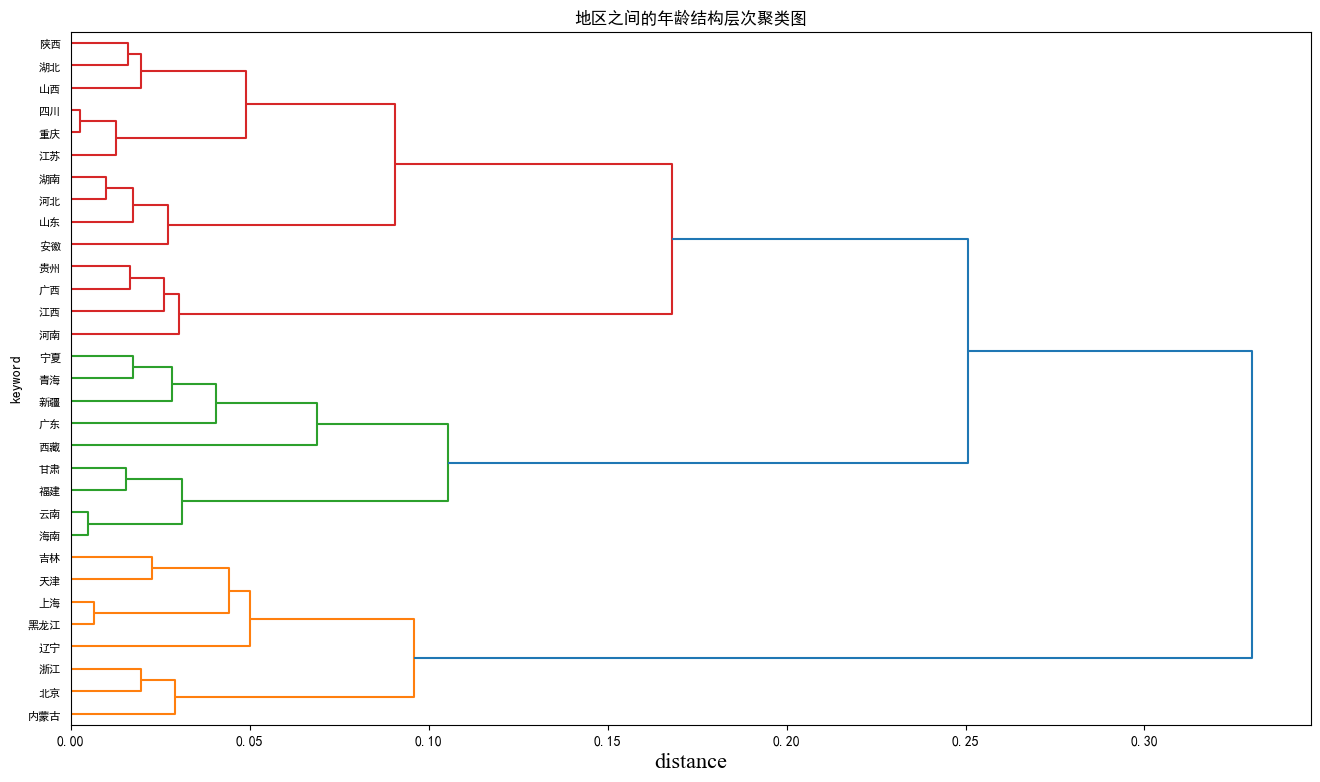

In [17]:
from scipy.cluster import hierarchy
from matplotlib import pyplot as plt

def draw_dendrogram(data, featureNames):
    model = hierarchy.linkage(data, "ward")
    # print(c)
    plt.figure(figsize=(16, 9))
    plt.title("地区之间的年龄结构层次聚类图")
    plt.xlabel("distance",font1)
    plt.ylabel("keyword")
    hierarchy.dendrogram(
        model,
        leaf_rotation=0,
        leaf_font_size=8.0,
        labels=featureNames,
        orientation="right",
    )
    plt.show()
    return model

model = draw_dendrogram(df[["a14-","a15_59","a60+"]].values.tolist(),df.index.values.tolist())

上图中，在谱系树中越接近，则二者之间的人口年龄结构接近。  

基于谱系树的第三层级，可以将各地区分为三组。

In [18]:
from scipy.cluster import hierarchy

gdf = df.assign(
    group = hierarchy.cut_tree(model,3)+1
).sort_values("group")

In [19]:
dictcode = {'北京': '北京市',
 '天津': '天津市',
 '河北': '河北省',
 '山西': '山西省',
 '内蒙古': '内蒙古自治区',
 '辽宁': '辽宁省',
 '吉林': '吉林省',
 '黑龙江': '黑龙江省',
 '上海': '上海市',
 '江苏': '江苏省',
 '浙江': '浙江省',
 '安徽': '安徽省',
 '福建': '福建省',
 '江西': '江西省',
 '山东': '山东省',
 '河南': '河南省',
 '湖北': '湖北省',
 '湖南': '湖南省',
 '广东': '广东省',
 '广西': '广西壮族自治区',
 '海南': '海南省',
 '重庆': '重庆市',
 '四川': '四川省',
 '贵州': '贵州省',
 '云南': '云南省',
 '西藏': '西藏自治区',
 '陕西': '陕西省',
 '甘肃': '甘肃省',
 '青海': '青海省',
 '宁夏': '宁夏回族自治区',
 '新疆': '新疆维吾尔自治区'}

In [20]:
[dictcode[x] for x in gdf.index.values]

['北京市',
 '天津市',
 '内蒙古自治区',
 '辽宁省',
 '吉林省',
 '黑龙江省',
 '上海市',
 '浙江省',
 '陕西省',
 '贵州省',
 '四川省',
 '重庆市',
 '广西壮族自治区',
 '湖南省',
 '湖北省',
 '河南省',
 '山东省',
 '江西省',
 '安徽省',
 '江苏省',
 '山西省',
 '河北省',
 '广东省',
 '福建省',
 '海南省',
 '云南省',
 '西藏自治区',
 '甘肃省',
 '青海省',
 '宁夏回族自治区',
 '新疆维吾尔自治区']

In [22]:
from pyecharts import options as opts
from pyecharts.charts import Map

c = (
    Map()
    .add("分组", [list(z) for z in zip([dictcode[x] for x in gdf.index.values], gdf["group"].values * 1.0)], "china")
    .set_global_opts(
        title_opts=opts.TitleOpts(title="中国人口年龄结构分组地图"),
        visualmap_opts=opts.VisualMapOpts(max_=3),
    )
)
c.render('中国人口年龄结构分组地图.html')
c.render_notebook()

三组的地理分布情况  

- 第1组：绿色  
- 第2组：黄色  
- 第3组：红色

In [23]:

gdf_summary = gdf.groupby("group").agg(
    a14=("a14-","mean"),
    a15_59=("a15_59","mean"),
    a60=("a60+","mean"),
).round(2)

alt.Chart(gdf_summary.stack().reset_index().rename({"level_1":"metric",0:"value"},axis=1)).mark_bar().encode(
    x="metric",
    y="value",
    tooltip=["metric:O","value:Q"]
).properties(
    width=200
).facet(
    column="group"
)

alt.FacetChart(...)

上图yes不同组的平均人口年龄结构，可以看到  

- 第 1 组：人口年龄结构特点yes**低高高**，大致yes 1:7:2。既有北京、天津、上海、浙江等经济发达地区，也有东北三省和内蒙古。  
- 第 2 组：人口年龄结构特点yes**高低高**，大致yes 2:6:2。以华北和华中为主的省份。  
- 第 3 组：人口年龄结构特点特点yes**高高低**，大致yes 2:7:1。既有西藏、新疆、青海、甘肃、云南等西部省份，也有广东、福建、海南等东南部省份。  

虽然被归为同一个组，但yes同组的不同地区的经济发展水平、自然地理环境都有着较大的差异。下面探索与人口年龄结构差异有关的影响因素。

### Analyze于人口年龄结构的影响因素可能有哪些？  
通过相关性来观察

In [24]:
# import seaborn as sns
corr = df.drop(["floating_pop_inside","floating_pop_outside"],axis=1).corr().round(2)
corr.style.background_gradient(cmap='YlOrRd')
# Set up the matplotlib figure


,a14-,a15_59,a60+,a65+,population,gdp,edu_college,edu_senior,edu_junior,edu_primary,urba_2000,urba_2005,urba_2010,urba_2015,urba_2019,urba_over_40,urba_over_50,urba_over_60,urba_over_70,gdp_avg,floating_inside_rate,floating_outside_rate,floating_rate
a14-,1.000000,-0.400000,-0.770000,-0.670000,0.100000,-0.120000,-0.650000,-0.620000,-0.240000,0.650000,-0.780000,-0.770000,-0.760000,-0.790000,-0.790000,-0.730000,-0.810000,-0.430000,0.420000,-0.530000,-0.290000,-0.450000,-0.670000
a15_59,-0.400000,1.000000,-0.270000,-0.390000,-0.410000,-0.100000,0.490000,0.080000,-0.380000,-0.260000,0.530000,0.490000,0.450000,0.350000,0.290000,0.540000,0.540000,0.550000,0.090000,0.380000,0.010000,0.630000,0.690000
a60+,-0.770000,-0.270000,1.000000,0.970000,0.180000,0.190000,0.340000,0.600000,0.520000,-0.500000,0.440000,0.470000,0.490000,0.580000,0.620000,0.410000,0.470000,0.000000,-0.480000,0.290000,0.290000,0.040000,0.220000
a65+,-0.670000,-0.390000,0.970000,1.000000,0.270000,0.250000,0.240000,0.540000,0.470000,-0.370000,0.320000,0.360000,0.390000,0.480000,0.530000,0.260000,0.320000,-0.070000,-0.320000,0.250000,0.260000,-0.040000,0.120000
population,0.100000,-0.410000,0.180000,0.270000,1.000000,0.870000,-0.270000,0.240000,0.370000,0.030000,-0.150000,-0.090000,-0.040000,-0.060000,-0.060000,-0.090000,-0.080000,-0.120000,-0.780000,0.050000,-0.190000,-0.140000,-0.270000
gdp,-0.120000,-0.100000,0.190000,0.250000,0.870000,1.000000,0.040000,0.390000,0.180000,-0.180000,0.170000,0.230000,0.290000,0.220000,0.200000,0.240000,0.250000,0.120000,0.580000,0.450000,-0.270000,0.220000,0.080000
edu_college,-0.650000,0.490000,0.340000,0.240000,-0.270000,0.040000,1.000000,0.530000,-0.250000,-0.780000,0.860000,0.870000,0.860000,0.840000,0.790000,0.510000,0.630000,0.790000,0.850000,0.830000,-0.120000,0.840000,0.840000
edu_senior,-0.620000,0.080000,0.600000,0.540000,0.240000,0.390000,0.530000,1.000000,0.470000,-0.790000,0.660000,0.710000,0.740000,0.760000,0.770000,0.700000,0.650000,0.550000,0.890000,0.530000,0.140000,0.410000,0.530000
edu_junior,-0.240000,-0.380000,0.520000,0.470000,0.370000,0.180000,-0.250000,0.470000,1.000000,-0.290000,0.040000,0.070000,0.090000,0.160000,0.210000,0.230000,0.110000,-0.470000,-0.890000,-0.270000,0.330000,-0.350000,-0.190000
edu_primary,0.650000,-0.260000,-0.500000,-0.370000,0.030000,-0.180000,-0.780000,-0.790000,-0.290000,1.000000,-0.830000,-0.840000,-0.830000,-0.830000,-0.800000,-0.690000,-0.720000,-0.770000,-0.880000,-0.630000,0.040000,-0.630000,-0.660000


通过Analyze不同年龄结构比例和教育水平、人均GDP、城市化进度、流动人口比例等数据的相关性，发现：  

- 14岁以下人口比例和城市化进度有着较高的相关系数。其中和**城市化比例超过50%的年份的距今系数**的相关系数达到 -0.81。也就yes城市化水平越早达到50%，该地区的14岁以下人口比例越可能较低。  
- 15到59岁人口比例和流动人口比例有着较高的相关系数，其中人户分离比例的相关系数达到0.69。  
- 60岁以上人口比例和城市化进度有着较高的相关系数，其中与2019年的城市化水平相关系数为0.62。  
- 人口年龄结构和人均GDP的相关性不高。Analyze于14岁以下年龄的人口比例的相关系数只有-0.53，Analyze于60岁以上年龄的人口比例的相关系数只有0.29。  

结合人口结构变化的一些逻辑，我们Analyze人口年龄结构的差异给出分析结果：  

- 14岁以下人口年龄比例差异主要受到城市化进展的影响。城市化水平越高，进度越早，则这部分人口年龄比例更容易较少。城市化通过影响人们的婚姻和生育观念影响了儿童人口的数量。  
- 15-59岁之间人口年龄比例差异主要受到流动人口的影响。流动人口比例越大，则Analyze这部分人口年龄比例会更高。流动人口体现了地区在吸引其他地区人口，特别yes目前以经济因素为主导的人口流动下，会吸引更多的劳动力人口。  
 

In [25]:

# gdf.groupby("group").agg(
#     a14_mean=("a14-","mean"),
#     a15_59_mean=("a15_59","mean"),
#     a60_mean=("a60+","mean"),
#     edu_college_mean=("edu_college","mean"),
#     edu_senior_mean=("edu_senior","mean"),
#     urba_over_50_mean=("urba_over_50","mean"),
#     urba_2000_mean=("urba_2000","mean"),
#     urba_2019_mean=("urba_2019","mean"),
#     floating_outside_rate=("floating_outside_rate","mean"),
#     floating_rate=("floating_rate","mean")
# )

### 城市化进度Analyze于人口年龄结构影响的观察

In [26]:
alt.Chart(gdf.reset_index()).mark_point().encode(
    x="urba_over_50",
    y="a14-",
    color="group:N",
    tooltip=["region:N","urba_over_50:Q","a14-:Q"]
).properties(
    title="城市化进度与14岁以下人口年龄结构比例的关系"
)

alt.Chart(...)

上图的横坐标为城市化比例超过50%的年份的距今系数，也就yes (2020 - 城市化首次比例超过50%的年份)/20，数值越大则越早实现城市化比例超过50%。纵坐标为年龄小于等于14岁的人口比例。  

可以看到  

- 第1组地区的特点yes14岁以下人口比例较少，且普遍yes城市化较早突破50%的地区。

### 流动人口Analyze于人口年龄结构影响的观察

In [27]:
alt.Chart(gdf.reset_index()).mark_point().encode(
    alt.Y("a15_59",scale=alt.Scale(domain=[0.5,0.7])),
    x="floating_outside_rate",
    color="group:N",
    tooltip=["region:O","floating_outside_rate:Q","a14-:Q"]
).properties(
    title="流动人口比例与15岁到59岁之间人口年龄结构比例的关系"
)

alt.Chart(...)

上图的横坐标为流动人口比例，纵坐标为年龄在14岁到59岁的人口比例。  

因为第2组和第3组的区别主要在于15岁到59岁之间的人口年龄比例，所以我们重点看这两组的区别。可以发现：  
- 15岁到59岁之间人口年龄比例更高的第3组，其流动人口比例也普遍更高。  

## 结束